Dataset: `titanic_dataset.csv`

Topics:
- Numerical: mean, median, mode, variance, std
- Skewness and kurtosis
- Histograms, boxplots
- Categorical: frequency tables, countplots

In [1]:
%pip install -q pandas numpy seaborn matplotlib


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


np.random.seed(42)
pd.set_option("display.max_columns", 50)
sns.set_style("whitegrid")

In [3]:
df = pd.read_csv("titanic_dataset.csv")

In [4]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [22]:
print(df.loc[2,'age']) # Display the value in the "age" column for the third row of the DataFrame to check for any potential issues with that specific value

print(df.loc[0:2,'age']) 
# Display the "age" column for the first three rows of the DataFrame to check for any potential issues with the data in that column

26.0
0    22.0
1    38.0
2    26.0
Name: age, dtype: float64


In [ ]:
print(df.iloc[3,6]) # Display the value in the 7th column for the fourth row of the DataFrame to check for any potential issues with that specific value  
print(df.iloc[0:3,6]) # Display the values in the 7th column for the first three rows of the DataFrame to check for any potential issues with the data in that column

53.1
0     7.2500
1    71.2833
2     7.9250
Name: fare, dtype: float64


In [26]:
df.groupby("pclass")["fare"].agg(["mean", "median", "min", "max"])

,mean,median,min,max
pclass,,,,
1,84.154687,60.2875,0.0,512.3292
2,20.662183,14.2500,0.0,73.5000
3,13.675550,8.0500,0.0,69.5500


In [29]:
df.groupby(["pclass", "sex"])["fare"].agg(["mean", "median", "min", "max"])

mean    median      min       max
pclass sex                                            
1      female  106.125798  82.66455  25.9292  512.3292
       male     67.226127  41.26250   0.0000  512.3292
2      female   21.970121  22.00000  10.5000   65.0000
       male     19.741782  13.00000   0.0000   73.5000
3      female   16.118810  12.47500   6.7500   69.5500
       male     12.661633   7.92500   0.0000   69.5500

In [5]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

| Column        | Description                                        | Feature Type                |
|---------------|----------------------------------------------------|-----------------------------|
| survived      | Whether the passenger survived (1) or not (0)      | Numerical (binary)          |
| pclass        | Passenger travel class (1, 2, 3)                   | Numerical (categorical encoded) |
| sex           | Passenger gender                                   | Categorical                 |
| age           | Passenger age in years                             | Numerical                   |
| sibsp         | Number of siblings or spouses aboard               | Numerical                   |
| parch         | Number of parents or children aboard               | Numerical                   |
| fare          | Ticket fare paid                                   | Numerical                   |
| embarked      | Port where passenger boarded (C, Q, S)             | Categorical                 |
| class         | Passenger class label (First, Second, Third)       | Categorical                 |
| who           | Person type (man, woman, child)                    | Categorical                 |
| adult_male    | Whether passenger is an adult male (True or False) | Categorical (boolean)       |
| deck          | Deck letter where cabin is located                 | Categorical                 |
| embark_town   | Town corresponding to embark point                 | Categorical                 |
| alive         | Survival status (yes or no) (repeated)             | Categorical                 |
| alone         | Whether the passenger traveled alone               | Categorical (boolean)       |

In [6]:
# Identify numerical and categorical features
num_cols = ["age", "fare", "sibsp", "parch"]
cat_cols = ["survived", "pclass", "sex", "embarked", "class", "who", "adult_male", "deck", "embark_town", "alone"]

print("\nNumerical columns:", num_cols)
print("Categorical columns:", cat_cols)


Numerical columns: ['age', 'fare', 'sibsp', 'parch']
Categorical columns: ['survived', 'pclass', 'sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alone']


### 3. Numerical Features - Analysis

In [8]:
df[['age','fare']].head()

,age,fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500


In [7]:
df[num_cols].head()

,age,fare,sibsp,parch
0,22.0,7.2500,1,0
1,38.0,71.2833,1,0
2,26.0,7.9250,0,0
3,35.0,53.1000,1,0
4,35.0,8.0500,0,0


2.1. Summary statistics

In [9]:
print("Summary Statistics:")
df[num_cols].describe()

Summary Statistics:


,age,fare,sibsp,parch
count,714.000000,891.000000,891.000000,891.000000
mean,29.699118,32.204208,0.523008,0.381594
std,14.526497,49.693429,1.102743,0.806057
min,0.420000,0.000000,0.000000,0.000000
25%,20.125000,7.910400,0.000000,0.000000
50%,28.000000,14.454200,0.000000,0.000000
75%,38.000000,31.000000,1.000000,0.000000
max,80.000000,512.329200,8.000000,6.000000


2.2. Mean, Median, Mode

In [10]:
print("Mean:")
print(df[num_cols].mean())

print("-"*50)

print("Median:")
print(df[num_cols].median())

print("-"*50)

print("Mode:")
print(df[num_cols].mode().iloc[0])

Mean:
age      29.699118
fare     32.204208
sibsp     0.523008
parch     0.381594
dtype: float64
--------------------------------------------------
Median:
age      28.0000
fare     14.4542
sibsp     0.0000
parch     0.0000
dtype: float64
--------------------------------------------------
Mode:
age      24.00
fare      8.05
sibsp     0.00
parch     0.00
Name: 0, dtype: float64


2.3. Variance & Standard Deviation

In [11]:
print("Variance:")
print(df[num_cols].var())

print("-"*50)

print("Standard Deviation:")
print(df[num_cols].std())

Variance:
age       211.019125
fare     2469.436846
sibsp       1.216043
parch       0.649728
dtype: float64
--------------------------------------------------
Standard Deviation:
age      14.526497
fare     49.693429
sibsp     1.102743
parch     0.806057
dtype: float64



3.4. Skewness & Kurtosis


In [12]:
print("\nSkewness:")
print(df[num_cols].skew())

print("\nKurtosis:")
print(df[num_cols].kurtosis())


Skewness:
age      0.389108
fare     4.787317
sibsp    3.695352
parch    2.749117
dtype: float64

Kurtosis:
age       0.178274
fare     33.398141
sibsp    17.880420
parch     9.778125
dtype: float64


3.5. Histograms

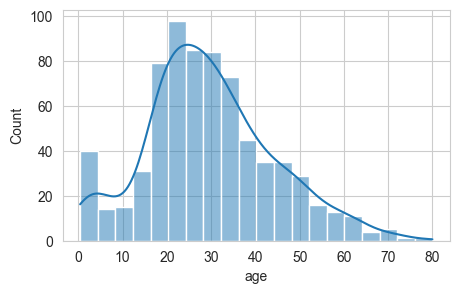

In [13]:
plt.figure(figsize=(5,3))
sns.histplot(df["age"], kde=True)
plt.show()

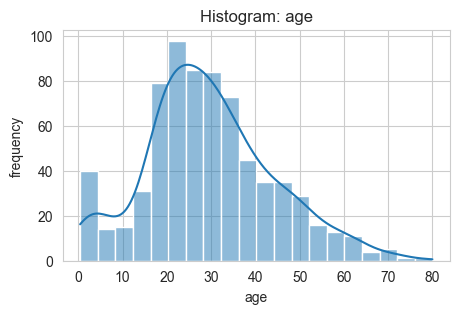

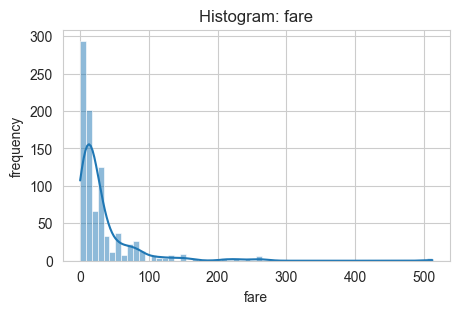

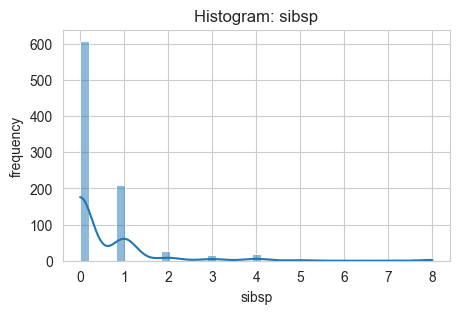

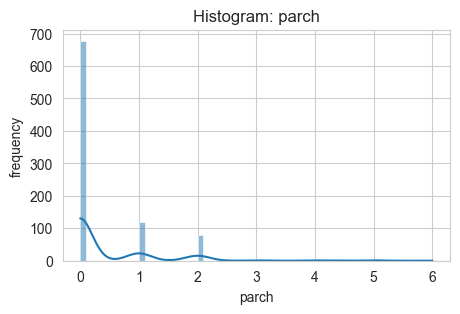

In [14]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(df[col], kde=True)
    plt.title(f"Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel("frequency")
    plt.show()

3.6. Boxplots

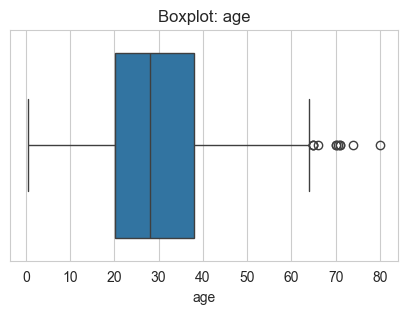

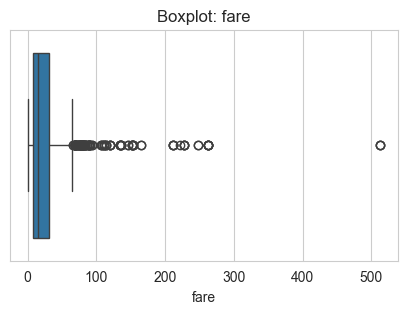

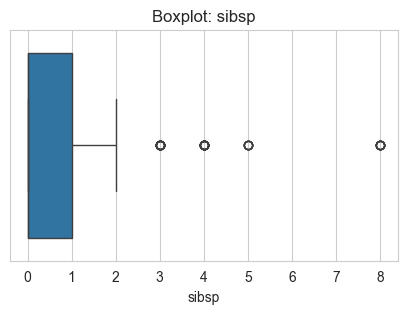

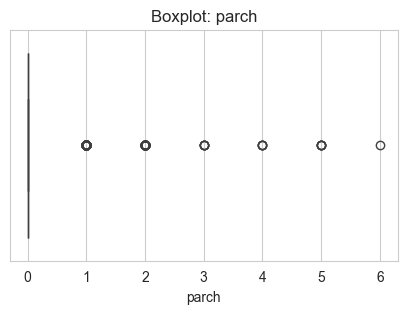

In [15]:
for col in num_cols:
    plt.figure(figsize=(5, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot: {col}")
    plt.xlabel(col)
    plt.show()

### 4. Categorical Features - Analysis

In [16]:
df[cat_cols].head()

,survived,pclass,sex,embarked,class,who,adult_male,deck,embark_town,alone
0,0,3,male,S,Third,man,True,NaN,Southampton,False
1,1,1,female,C,First,woman,False,C,Cherbourg,False
2,1,3,female,S,Third,woman,False,NaN,Southampton,True
3,1,1,female,S,First,woman,False,C,Southampton,False
4,0,3,male,S,Third,man,True,NaN,Southampton,True


4.1. Frequency Table

In [17]:
print(df["pclass"].value_counts())
print("-"*50)
print(df["pclass"].value_counts(normalize=True))

pclass
3    491
1    216
2    184
Name: count, dtype: int64
--------------------------------------------------
pclass
3    0.551066
1    0.242424
2    0.206510
Name: proportion, dtype: float64


In [18]:
for col in cat_cols:
    print(f"Frequency table for {col}")
    print(df[col].value_counts())
    print(f"Proportion for {col}")
    print(df[col].value_counts(normalize=True))
    print("-"*50)

Frequency table for survived
survived
0    549
1    342
Name: count, dtype: int64
Proportion for survived
survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64
--------------------------------------------------
Frequency table for pclass
pclass
3    491
1    216
2    184
Name: count, dtype: int64
Proportion for pclass
pclass
3    0.551066
1    0.242424
2    0.206510
Name: proportion, dtype: float64
--------------------------------------------------
Frequency table for sex
sex
male      577
female    314
Name: count, dtype: int64
Proportion for sex
sex
male      0.647587
female    0.352413
Name: proportion, dtype: float64
--------------------------------------------------
Frequency table for embarked
embarked
S    644
C    168
Q     77
Name: count, dtype: int64
Proportion for embarked
embarked
S    0.724409
C    0.188976
Q    0.086614
Name: proportion, dtype: float64
--------------------------------------------------
Frequency table for class
class
Third     491
First   

**Key findings - Univariate Analysis:**

Univariate analysis helps us understand each feature independently before modeling. Here is what we learned from the Titanic dataset:

- Numerical features show varying scales and strong skewness, especially fare. This indicates a need for scaling and possibly log transformation. Age has moderate variability and can be imputed reliably.
- Categorical features show clear imbalance in groups like sex, pclass, and embarked. These patterns will influence the model and require careful encoding.
- Outliers are present in fare and family related columns. Tree based models handle them well, but linear models will need scaling or outlier treatment.
- Most passengers traveled alone, which supports creating engineered features like family_size for improved predictions.
- Visualizations like histograms and boxplots reveal distribution shape, long tails, and unusual values, while countplots expose dominance of certain categories.
